In [10]:
import pandas as pd
import numpy as np
import seaborn as sns

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [11]:
design_matrix = pd.read_csv(
    "design_matrix_train.tsv",
    sep='\t'
)

In [12]:
design_matrix_test = pd.read_csv(
    "design_matrix_test.tsv",
    sep='\t'
)

design_matrix_validation = pd.read_csv(
    "design_matrix_validation.tsv",
    sep='\t'
)

design_matrix_hero = pd.read_csv(
    "design_matrix_hero.tsv",
    sep='\t'
)

In [13]:
design_matrix_sepsis_alert = pd.concat(
    [design_matrix, design_matrix_test, design_matrix_validation],
    ignore_index=True
)

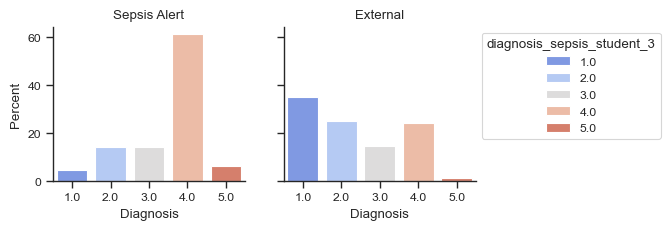

In [31]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    sharey=True,
)


axs = axs.ravel()

sns.countplot(
    data=design_matrix_sepsis_alert,
    x="diagnosis_sepsis_student_3",
    hue="diagnosis_sepsis_student_3",
    stat="percent",
    ax=axs[0],
    legend=False,
    palette=sns.color_palette("coolwarm", n_colors=5)
)

sns.countplot(
    data=design_matrix_hero,
    x="diagnosis_sepsis_student_3",
    hue="diagnosis_sepsis_student_3",
    stat="percent",
    ax=axs[1],
    palette=sns.color_palette("coolwarm", n_colors=5)
)

sns.move_legend(axs[1], "upper left", bbox_to_anchor=(1, 1))

fig.set_size_inches((8.27 * .66, 2))

axs[0].set_ylabel("Percent")
axs[0].set_xlabel("Diagnosis")
axs[1].set_xlabel("Diagnosis")

axs[0].set_title("Sepsis Alert")
axs[1].set_title("External")

fig.savefig(
    "diagnosis_distribution.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)